<a href="https://colab.research.google.com/github/KunjalGarg27/Smartphone-Addiction-Prediction-Using-Machine-Learning/blob/main/SVM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# STEP 1: IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# =========================
# STEP 2: LOAD DATASET
# =========================

# Load dataset
df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(df.head())

# Display shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumns in Dataset:")
print(df.columns.tolist())

First 5 Rows of Dataset:
  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1

In [ ]:
# =========================
# STEP 3: INITIAL DATA ANALYSIS
# =========================

# Basic dataset information
print("Dataset Info:\n")
print(df.info())

# Check missing values
print("\nMissing Values Per Column:\n")
print(df.isnull().sum())

# Check duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {duplicates}")

# Statistical summary for numerical columns
print("\nStatistical Summary:\n")
print(df.describe())

# Display unique values for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].unique())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction

Updated Columns:

Index(['age', 'gender', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

Updated Dataset Shape:
(7500, 13)
Numerical Columns for Outlier Detection:

Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'addicted_label'],
      dtype='object')

Feature: age
Q1: 22.0
Q3: 31.0
IQR: 9.0
Lower Bound: 8.5
Upper Bound: 44.5
Number of Outliers: 0

Feature: daily_screen_time_hours
Q1: 5.22
Q3: 9.81
IQR: 4.590000000000001
Lower Bound: -1.6650000000000018
Upper Bound: 16.695
Number of Outliers: 0

Feature: social_media_hours
Q1: 1.91
Q3: 4.63
IQR: 2.7199999999999998
Lower Bound: -2.17
Upper Bound: 8.71
Number of Outlie

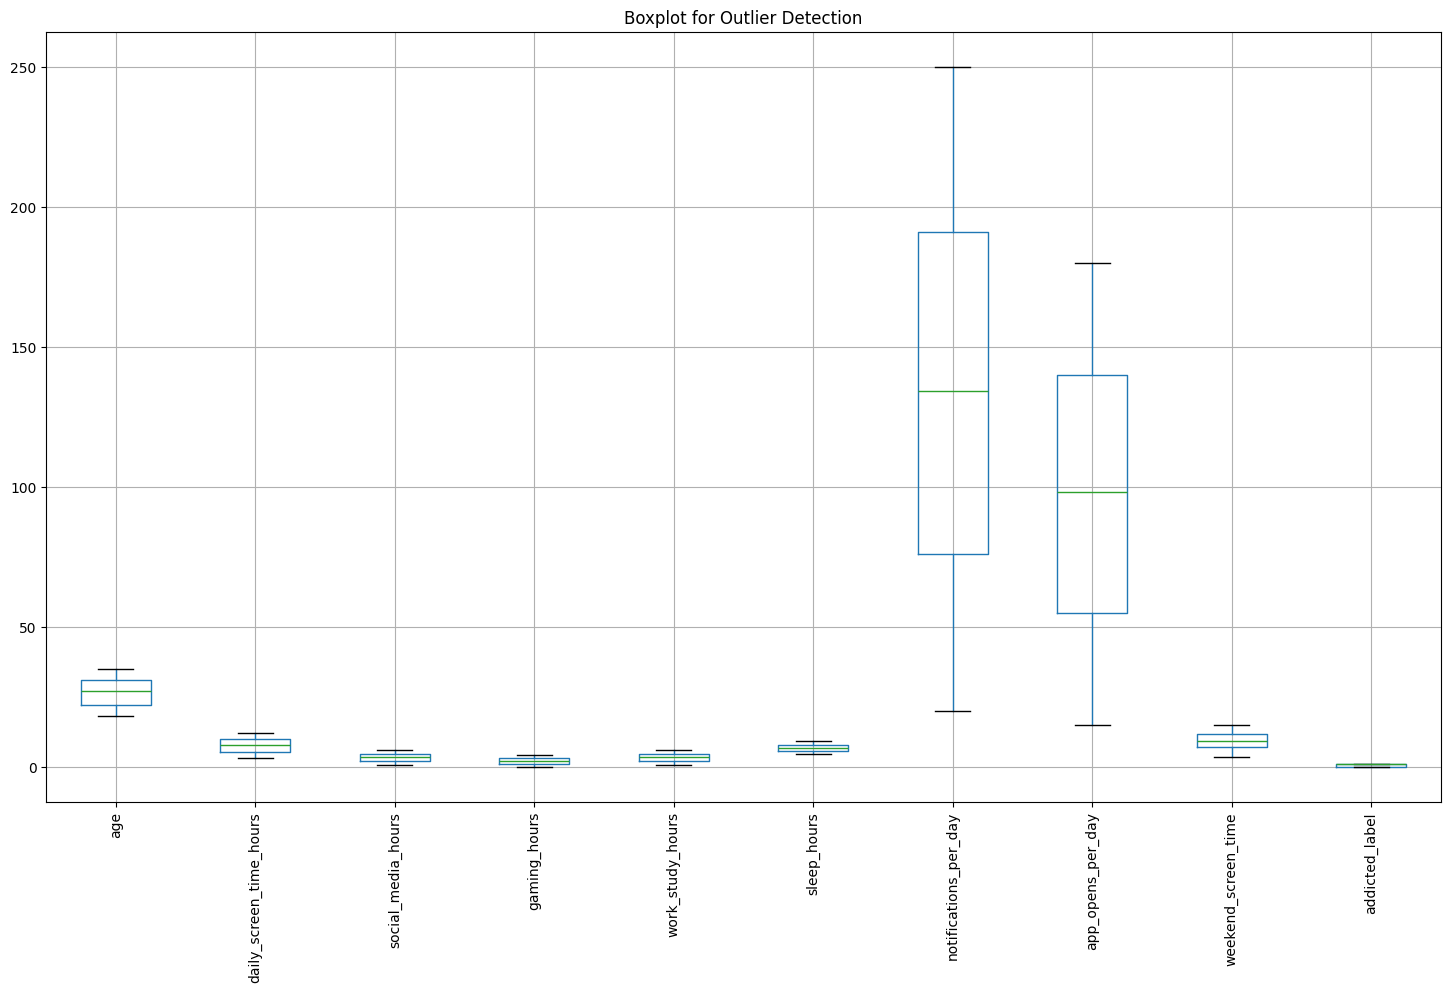

In [ ]:
# =========================
# STEP 4: DATA CLEANING
# =========================

# Dropping unnecessary columns
df.drop(columns=['transaction_id', 'user_id', 'addiction_level'], inplace=True)

# Verifying updated dataset
print("Updated Columns:\n")
print(df.columns)

# Check dataset shape after cleaning
print("\nUpdated Dataset Shape:")
print(df.shape)

# =========================
# OUTLIER DETECTION
# Using IQR Method on Numerical Columns
# =========================

# Create a copy of cleaned dataset before encoding
df_outlier = df.copy()

# Select numerical columns only
numerical_cols = df_outlier.select_dtypes(include=[np.number]).columns

print("Numerical Columns for Outlier Detection:\n")
print(numerical_cols)

# Dictionary to store outlier counts
outlier_summary = {}

# Detect outliers using IQR
for col in numerical_cols:
    Q1 = df_outlier[col].quantile(0.25)
    Q3 = df_outlier[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_outlier[(df_outlier[col] < lower_bound) | (df_outlier[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

    print(f"\nFeature: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")

# Convert summary to DataFrame
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier_Count'])

print("\nOutlier Summary Table:\n")
print(outlier_df)

# Boxplot visualization
plt.figure(figsize=(18, 10))
df_outlier[numerical_cols].boxplot(rot=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [ ]:
# =========================
# STEP 5: LABEL ENCODING
# =========================

from sklearn.preprocessing import LabelEncoder

# Create a copy for safe preprocessing
df_encoded = df.copy()

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns

# Dictionary to store encoders for reference
label_encoders = {}

# Apply Label Encoding
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

    # Display encoding mapping
    print(f"\nEncoding for '{col}':")
    for class_, value in zip(le.classes_, le.transform(le.classes_)):
        print(f"{class_} --> {value}")

# Display first few rows after encoding
print("\nEncoded Dataset Preview:")
print(df_encoded.head())

# Check updated data types
print("\nUpdated Data Types:")
print(df_encoded.dtypes)


Encoding for 'gender':
Female --> 0
Male --> 1
Other --> 2

Encoding for 'stress_level':
High --> 0
Low --> 1
Medium --> 2

Encoding for 'academic_work_impact':
No --> 0
Yes --> 1

Encoded Dataset Preview:
   age  gender  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   21       1                     3.23                2.01          0.89   
1   24       2                     5.09                3.81          2.24   
2   31       2                     6.06                1.36          3.83   
3   32       2                     7.83                5.85          1.51   
4   25       1                     9.96                5.92          3.42   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0              4.55         7.55                    248                154   
1              4.44         7.66                    127                 71   
2              2.35         4.92                     44                106   
3              3.5

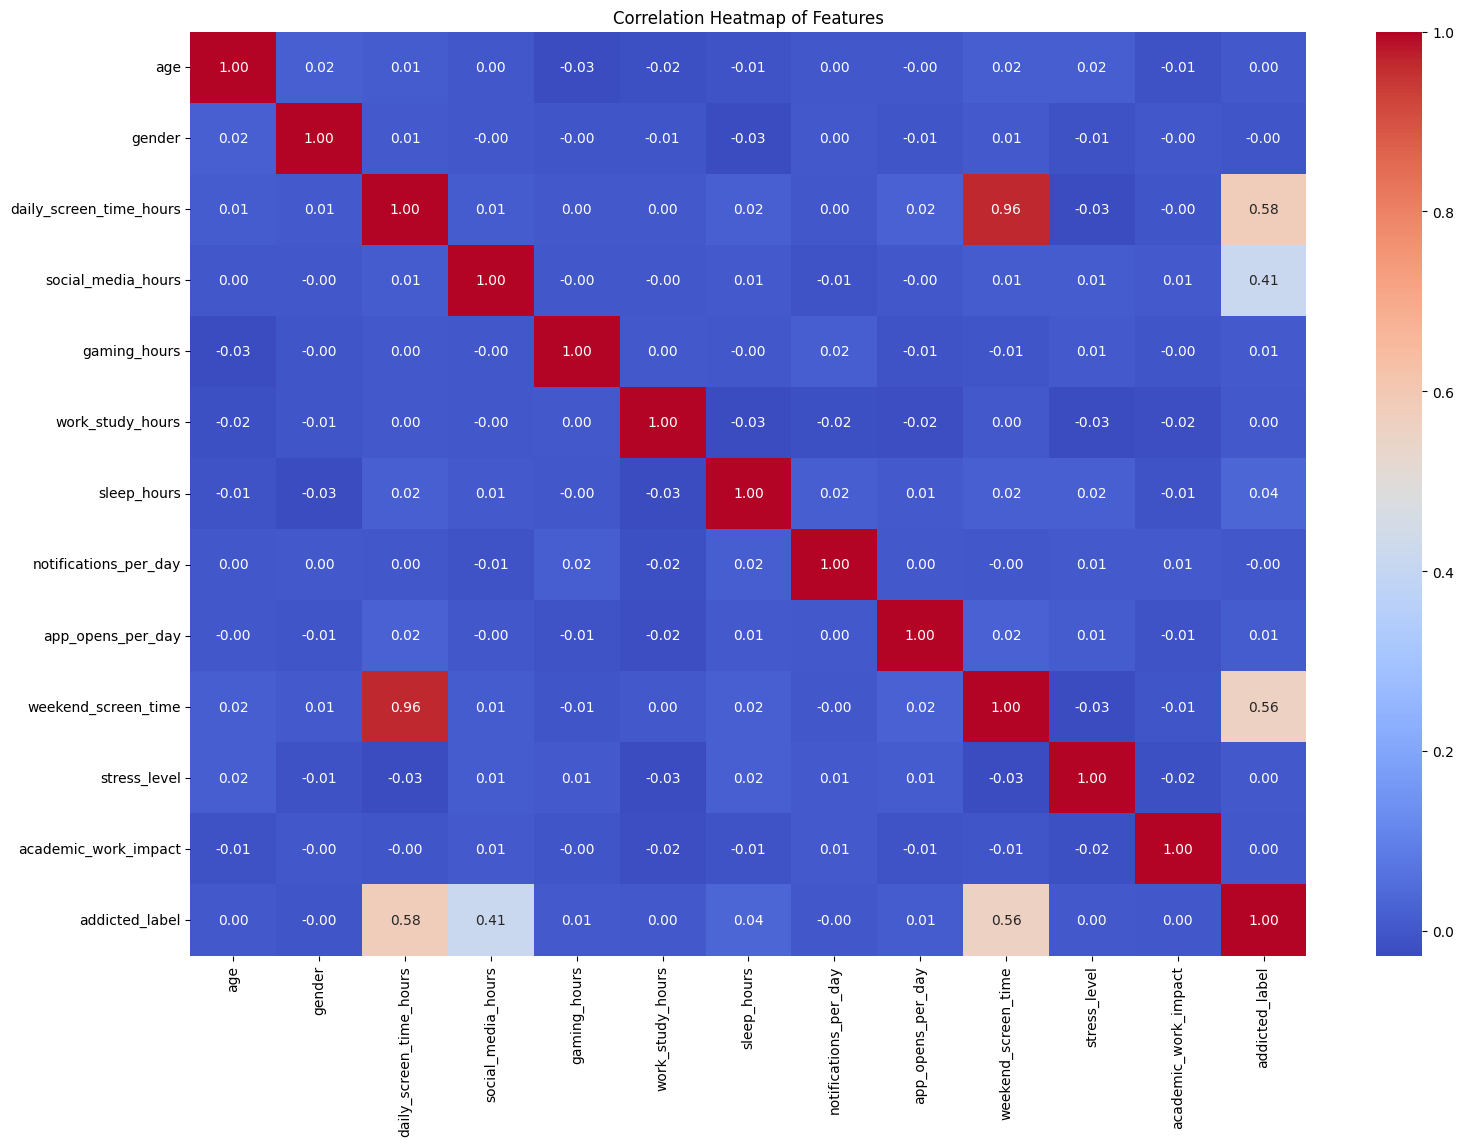

Feature Correlation with Target (addicted_label):

addicted_label             1.000000
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
social_media_hours         0.414244
sleep_hours                0.035496
app_opens_per_day          0.011041
gaming_hours               0.008485
age                        0.004220
stress_level               0.003970
work_study_hours           0.001103
academic_work_impact       0.000072
notifications_per_day     -0.000660
gender                    -0.003499
Name: addicted_label, dtype: float64

Selected Features based on correlation threshold:
['addicted_label', 'daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours']


In [ ]:
# =========================
# STEP 6A: FEATURE SELECTION (FILTER METHOD)
# Correlation Analysis + Heatmap
# =========================

# Correlation matrix
correlation_matrix = df_encoded.corr()

# Plot heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Features")
plt.show()

# Correlation with target variable
target_corr = correlation_matrix['addicted_label'].sort_values(ascending=False)

print("Feature Correlation with Target (addicted_label):\n")
print(target_corr)

# Optional: Select features above a threshold
threshold = 0.1
selected_features_filter = target_corr[abs(target_corr) > threshold].index.tolist()

print("\nSelected Features based on correlation threshold:")
print(selected_features_filter)

In [ ]:
# =========================
# STEP 6B: FEATURE SELECTION (WRAPPER METHOD)
# Recursive Feature Elimination (RFE)
# =========================

from sklearn.feature_selection import RFE
from sklearn.svm import SVC

# Separate features and target
X = df_encoded.drop('addicted_label', axis=1)
y = df_encoded['addicted_label']

# Use linear SVM estimator for RFE
svm_estimator = SVC(kernel='linear')

# Select top features (initial trial: top 5)
rfe = RFE(estimator=svm_estimator, n_features_to_select=5)

# Fit RFE
rfe.fit(X, y)

# Selected features
selected_features_rfe = X.columns[rfe.support_]

print("Selected Features using RFE:\n")
print(selected_features_rfe)

# Feature rankings
feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'Rank': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values(by='Rank')

print("\nFeature Ranking:\n")
print(feature_ranking)

Selected Features using RFE:

Index(['daily_screen_time_hours', 'social_media_hours', 'sleep_hours',
       'weekend_screen_time', 'stress_level'],
      dtype='object')

Feature Ranking:

                    Feature  Rank  Selected
3        social_media_hours     1      True
2   daily_screen_time_hours     1      True
6               sleep_hours     1      True
9       weekend_screen_time     1      True
10             stress_level     1      True
4              gaming_hours     2     False
5          work_study_hours     3     False
1                    gender     4     False
11     academic_work_impact     5     False
0                       age     6     False
7     notifications_per_day     7     False
8         app_opens_per_day     8     False


In [ ]:
# =========================
# STEP 7: FEATURE SCALING
# =========================

from sklearn.preprocessing import StandardScaler, MinMaxScaler

selected_features = ['social_media_hours', 'daily_screen_time_hours',
                     'sleep_hours', 'weekend_screen_time', 'stress_level']

X = df_encoded[selected_features]

# -------------------------
# BEFORE SCALING
# -------------------------
print("Original Feature Sample:\n")
print(X.head())

# -------------------------
# StandardScaler
# -------------------------
standard_scaler = StandardScaler()
X_standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(X),
    columns=selected_features
)

print("\nStandard Scaled Feature Sample:\n")
print(X_standard_scaled.head())

print("\nStandardScaler Statistics:\n")
print(X_standard_scaled.describe())

# -------------------------
# MinMaxScaler
# -------------------------
minmax_scaler = MinMaxScaler()
X_minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(X),
    columns=selected_features
)

print("\nMinMax Scaled Feature Sample:\n")
print(X_minmax_scaled.head())

print("\nMinMaxScaler Statistics:\n")
print(X_minmax_scaled.describe())

Original Feature Sample:

   social_media_hours  daily_screen_time_hours  sleep_hours  \
0                2.01                     3.23         7.55   
1                3.81                     5.09         7.66   
2                1.36                     6.06         4.92   
3                5.85                     7.83         8.23   
4                5.92                     9.96         6.21   

   weekend_screen_time  stress_level  
0                 3.95             2  
1                 6.71             2  
2                 8.68             0  
3                 9.77             0  
4                12.55             1  

Standard Scaled Feature Sample:

   social_media_hours  daily_screen_time_hours  sleep_hours  \
0           -0.797032                -1.636600     0.632977   
1            0.338446                -0.923687     0.718679   
2           -1.207066                -0.551899    -1.416076   
3            1.625320                 0.126518     1.162771   
4           

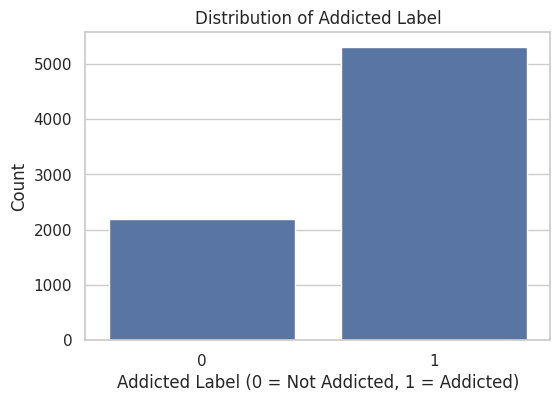

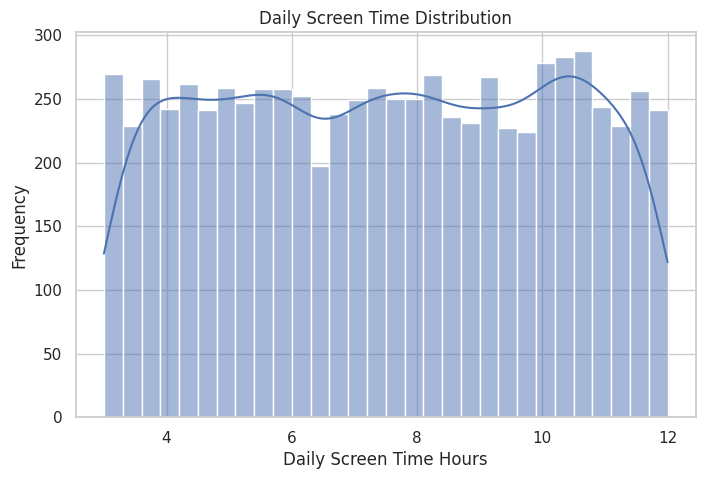

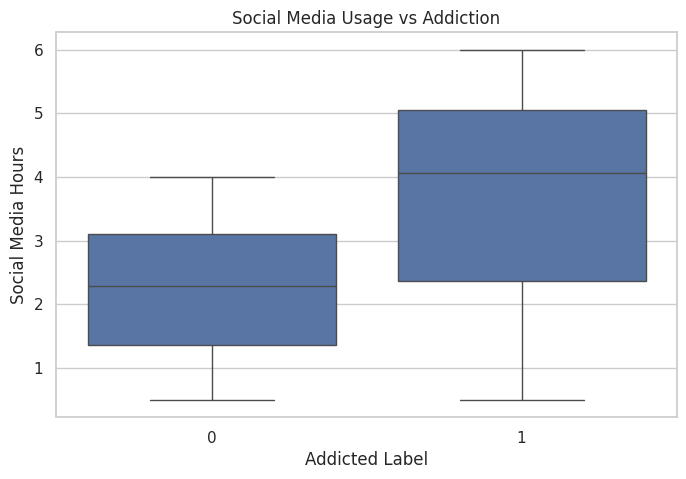

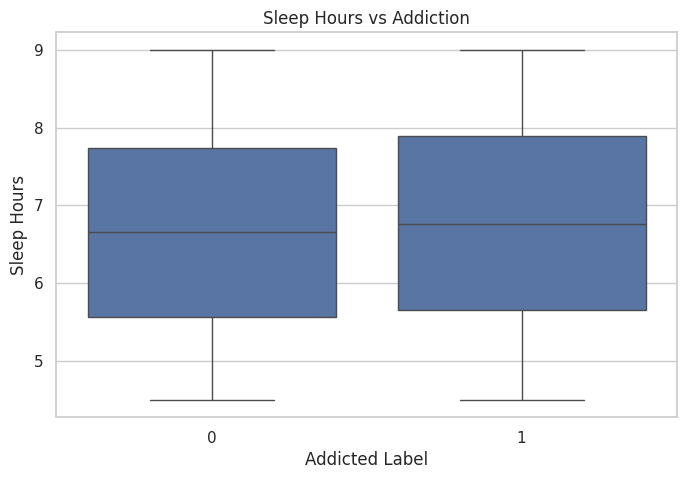

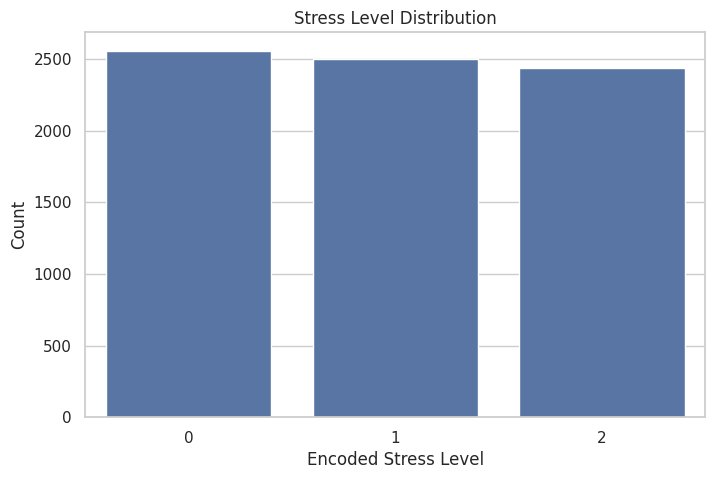

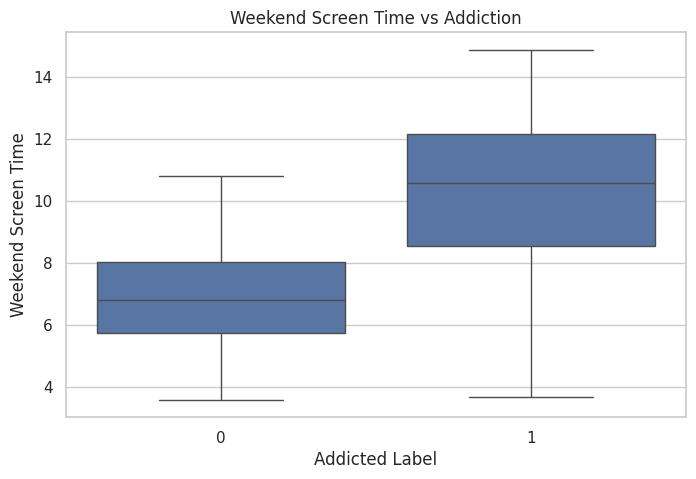

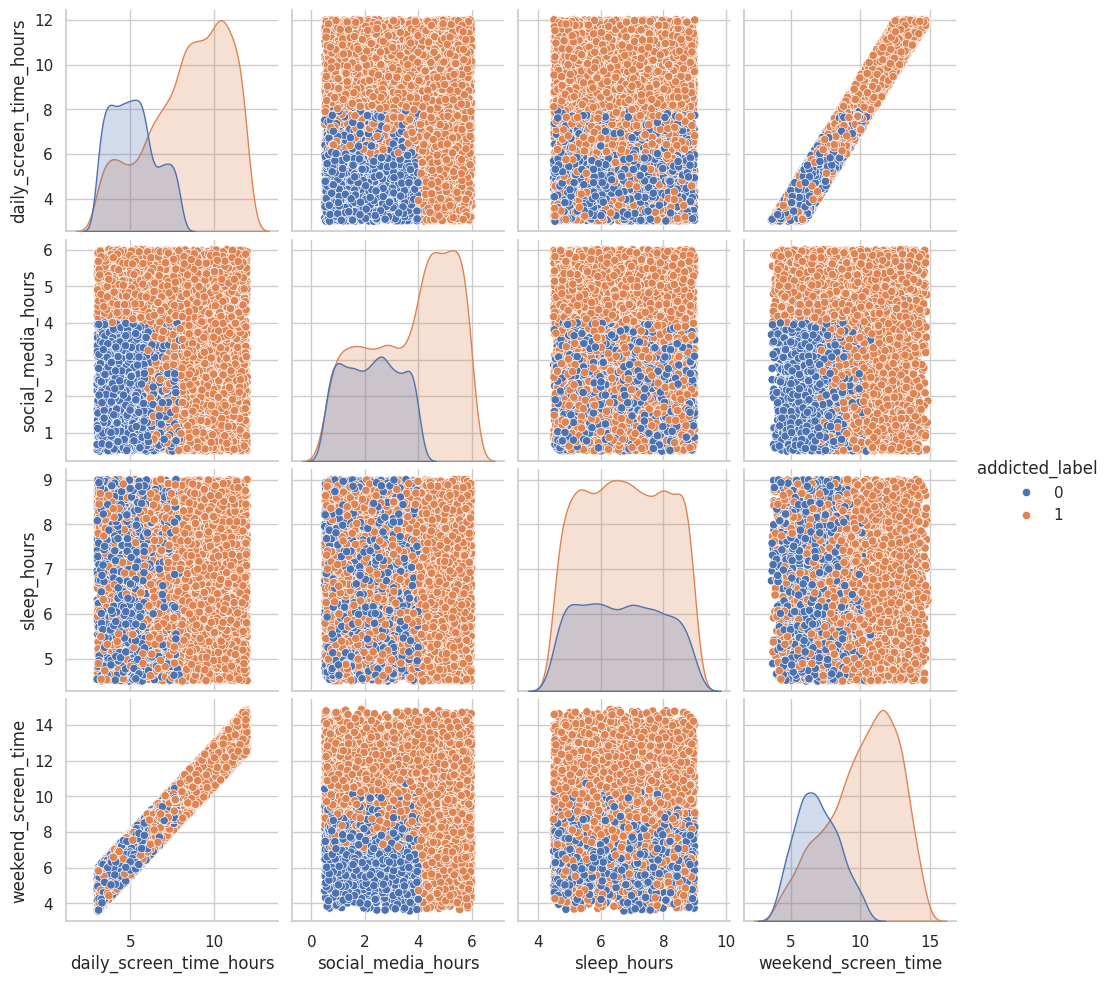

In [ ]:
# =========================
# STEP 8:  Data Visualization
# =========================

# Set style
sns.set(style="whitegrid")

# -------------------------
# 1. Target Variable Distribution
# -------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='addicted_label', data=df_encoded)
plt.title("Distribution of Addicted Label")
plt.xlabel("Addicted Label (0 = Not Addicted, 1 = Addicted)")
plt.ylabel("Count")
plt.show()

# -------------------------
# 2. Daily Screen Time Distribution
# -------------------------
plt.figure(figsize=(8,5))
sns.histplot(df_encoded['daily_screen_time_hours'], bins=30, kde=True)
plt.title("Daily Screen Time Distribution")
plt.xlabel("Daily Screen Time Hours")
plt.ylabel("Frequency")
plt.show()

# -------------------------
# 3. Social Media Hours vs Addiction
# -------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x='addicted_label', y='social_media_hours', data=df_encoded)
plt.title("Social Media Usage vs Addiction")
plt.xlabel("Addicted Label")
plt.ylabel("Social Media Hours")
plt.show()

# -------------------------
# 4. Sleep Hours vs Addiction
# -------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x='addicted_label', y='sleep_hours', data=df_encoded)
plt.title("Sleep Hours vs Addiction")
plt.xlabel("Addicted Label")
plt.ylabel("Sleep Hours")
plt.show()

# -------------------------
# 5. Stress Level Distribution
# -------------------------
if 'stress_level' in df_encoded.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x='stress_level', data=df_encoded)
    plt.title("Stress Level Distribution")
    plt.xlabel("Encoded Stress Level")
    plt.ylabel("Count")
    plt.show()

# -------------------------
# 6. Weekend Screen Time vs Addiction
# -------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x='addicted_label', y='weekend_screen_time', data=df_encoded)
plt.title("Weekend Screen Time vs Addiction")
plt.xlabel("Addicted Label")
plt.ylabel("Weekend Screen Time")
plt.show()

# -------------------------
# 7. Pairplot for Selected Key Features
# -------------------------
selected_eda_features = [
    'daily_screen_time_hours',
    'social_media_hours',
    'sleep_hours',
    'weekend_screen_time',
    'addicted_label'
]

sns.pairplot(df_encoded[selected_eda_features], hue='addicted_label')
plt.show()

In [ ]:
# =========================
# STEP 9: TRAIN-TEST SPLIT
# Comparing 80:20 and 70:30 splits
# =========================

from sklearn.model_selection import train_test_split

# Target variable
y = df_encoded['addicted_label']

# -------------------------
# Trial A: 80:20 Split
# -------------------------
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_standard_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("80:20 Split:")
print("X_train shape:", X_train_80.shape)
print("X_test shape:", X_test_80.shape)
print("y_train shape:", y_train_80.shape)
print("y_test shape:", y_test_80.shape)

# -------------------------
# Trial B: 70:30 Split
# -------------------------
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_standard_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\n70:30 Split:")
print("X_train shape:", X_train_70.shape)
print("X_test shape:", X_test_70.shape)
print("y_train shape:", y_train_70.shape)
print("y_test shape:", y_test_70.shape)

# Class distribution check
print("\nClass Distribution in 80:20 Training Set:")
print(y_train_80.value_counts(normalize=True))

print("\nClass Distribution in 80:20 Testing Set:")
print(y_test_80.value_counts(normalize=True))

80:20 Split:
X_train shape: (6000, 5)
X_test shape: (1500, 5)
y_train shape: (6000,)
y_test shape: (1500,)

70:30 Split:
X_train shape: (5250, 5)
X_test shape: (2250, 5)
y_train shape: (5250,)
y_test shape: (2250,)

Class Distribution in 80:20 Training Set:
addicted_label
1    0.707667
0    0.292333
Name: proportion, dtype: float64

Class Distribution in 80:20 Testing Set:
addicted_label
1    0.708
0    0.292
Name: proportion, dtype: float64


Baseline SVM Performance (Linear Kernel):

Accuracy: 0.8953
Precision: 0.9058
Recall: 0.9510
F1 Score: 0.9279


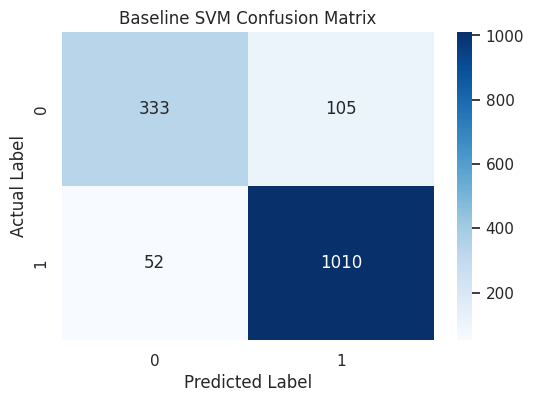


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.76      0.81       438
           1       0.91      0.95      0.93      1062

    accuracy                           0.90      1500
   macro avg       0.89      0.86      0.87      1500
weighted avg       0.89      0.90      0.89      1500



In [ ]:
# =========================
# STEP 10: BASELINE SVM MODEL
# Trial 1: Linear Kernel
# =========================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# -------------------------
# Train baseline SVM
# -------------------------
svm_baseline = SVC(kernel='linear', random_state=42)

svm_baseline.fit(X_train_80, y_train_80)

# Predictions
y_pred_baseline = svm_baseline.predict(X_test_80)

# -------------------------
# Performance Metrics
# -------------------------
baseline_accuracy = accuracy_score(y_test_80, y_pred_baseline)
baseline_precision = precision_score(y_test_80, y_pred_baseline)
baseline_recall = recall_score(y_test_80, y_pred_baseline)
baseline_f1 = f1_score(y_test_80, y_pred_baseline)

print("Baseline SVM Performance (Linear Kernel):\n")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall: {baseline_recall:.4f}")
print(f"F1 Score: {baseline_f1:.4f}")

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test_80, y_pred_baseline)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Baseline SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# -------------------------
# Classification Report
# -------------------------
print("\nClassification Report:\n")
print(classification_report(y_test_80, y_pred_baseline))

Kernel Comparison Results:

   Kernel  Accuracy  Precision    Recall  F1 Score
0  linear  0.895333   0.905830  0.951036  0.927882
1     rbf  0.926000   0.940686  0.955744  0.948155
2    poly  0.888000   0.881399  0.972693  0.924799


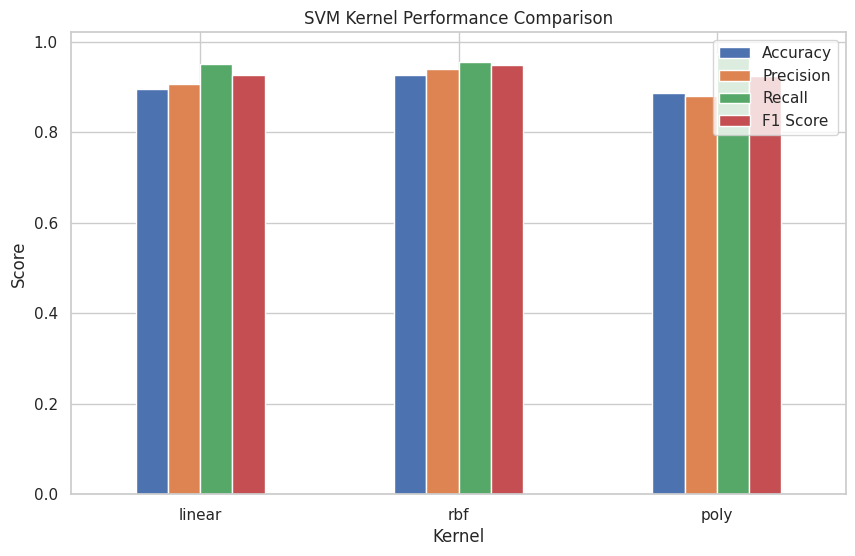

In [ ]:
# =========================
# STEP 11: KERNEL COMPARISON
# Linear vs RBF vs Polynomial
# =========================

kernels = ['linear', 'rbf', 'poly']

results = []

for kernel in kernels:
    svm_model = SVC(kernel=kernel, random_state=42)

    svm_model.fit(X_train_80, y_train_80)
    y_pred = svm_model.predict(X_test_80)

    accuracy = accuracy_score(y_test_80, y_pred)
    precision = precision_score(y_test_80, y_pred)
    recall = recall_score(y_test_80, y_pred)
    f1 = f1_score(y_test_80, y_pred)

    results.append({
        'Kernel': kernel,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

# Convert to DataFrame
kernel_results_df = pd.DataFrame(results)

print("Kernel Comparison Results:\n")
print(kernel_results_df)

# Visualization
kernel_results_df.set_index('Kernel')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("SVM Kernel Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Hyperparameter Tuning Results:

  Trial ID Kernel      C  Gamma  Accuracy  Precision    Recall  F1 Score
0   SVM_04    RBF    0.1  scale  0.916667   0.929423  0.954802  0.941941
1   SVM_05    RBF    1.0  scale  0.926000   0.940686  0.955744  0.948155
2   SVM_06    RBF   10.0  scale  0.930000   0.945946  0.955744  0.950820
3   SVM_07    RBF  100.0  scale  0.925333   0.947269  0.947269  0.947269
4   SVM_08    RBF    1.0   auto  0.926000   0.940686  0.955744  0.948155
5   SVM_09    RBF   10.0   auto  0.929333   0.945065  0.955744  0.950375
6   SVM_10    RBF    1.0    0.1  0.925333   0.942272  0.952919  0.947566
7   SVM_11    RBF    1.0   0.01  0.908667   0.923147  0.950094  0.936427


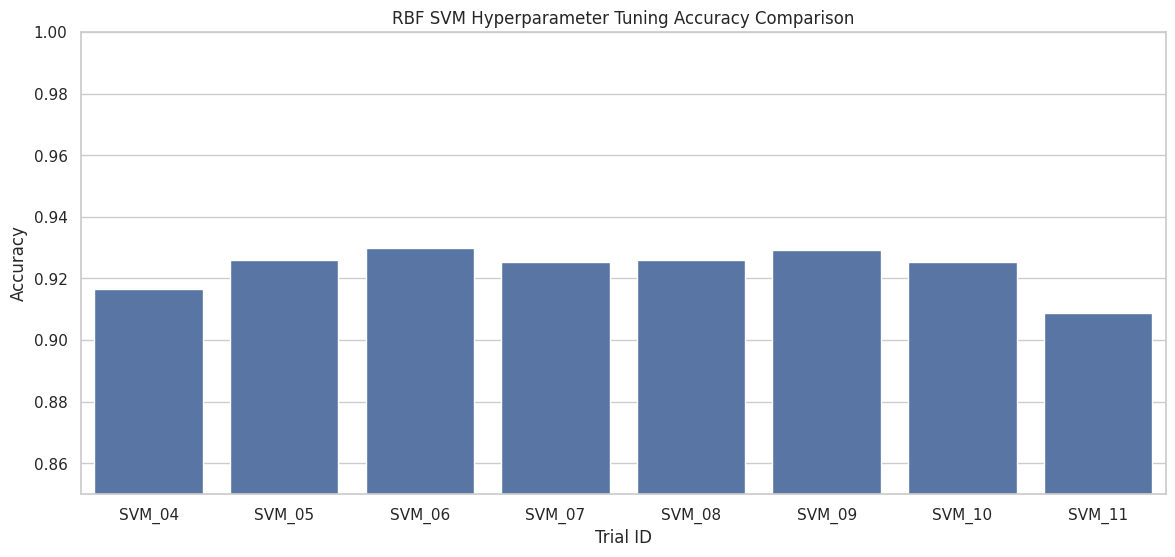

In [ ]:
# =========================
# STEP 12: HYPERPARAMETER TUNING (RBF KERNEL)
# Grid Search Style Trials
# =========================

# Parameter combinations
param_grid = [
    {'C': 0.1, 'gamma': 'scale'},
    {'C': 1, 'gamma': 'scale'},
    {'C': 10, 'gamma': 'scale'},
    {'C': 100, 'gamma': 'scale'},
    {'C': 1, 'gamma': 'auto'},
    {'C': 10, 'gamma': 'auto'},
    {'C': 1, 'gamma': 0.1},
    {'C': 1, 'gamma': 0.01},
]

tuning_results = []

trial_num = 4  # Starting after SVM_03

for params in param_grid:
    svm_tuned = SVC(
        kernel='rbf',
        C=params['C'],
        gamma=params['gamma'],
        random_state=42
    )

    svm_tuned.fit(X_train_80, y_train_80)
    y_pred = svm_tuned.predict(X_test_80)

    accuracy = accuracy_score(y_test_80, y_pred)
    precision = precision_score(y_test_80, y_pred)
    recall = recall_score(y_test_80, y_pred)
    f1 = f1_score(y_test_80, y_pred)

    tuning_results.append({
        'Trial ID': f'SVM_{trial_num:02d}',
        'Kernel': 'RBF',
        'C': params['C'],
        'Gamma': params['gamma'],
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    trial_num += 1

# Convert results to DataFrame
tuning_results_df = pd.DataFrame(tuning_results)

print("Hyperparameter Tuning Results:\n")
print(tuning_results_df)

# Visualization
plt.figure(figsize=(14,6))
sns.barplot(x='Trial ID', y='Accuracy', data=tuning_results_df)
plt.title("RBF SVM Hyperparameter Tuning Accuracy Comparison")
plt.ylim(0.85, 1.0)
plt.show()

Final Optimized SVM Performance:

Accuracy: 0.9300
Precision: 0.9459
Recall: 0.9557
F1 Score: 0.9508


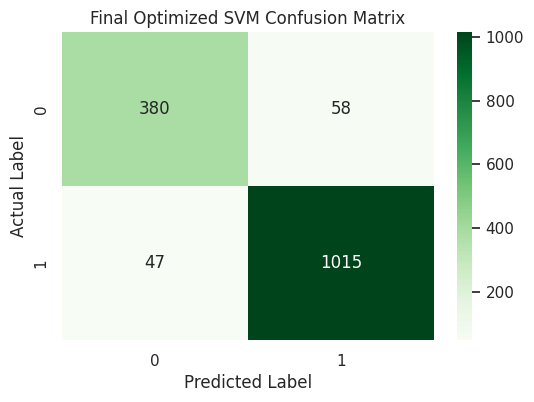


Final Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       438
           1       0.95      0.96      0.95      1062

    accuracy                           0.93      1500
   macro avg       0.92      0.91      0.91      1500
weighted avg       0.93      0.93      0.93      1500


Baseline vs Final Model Comparison:

      Metric  Baseline Linear SVM  Final Optimized SVM
0   Accuracy             0.895333             0.930000
1  Precision             0.905830             0.945946
2     Recall             0.951036             0.955744
3   F1 Score             0.927882             0.950820


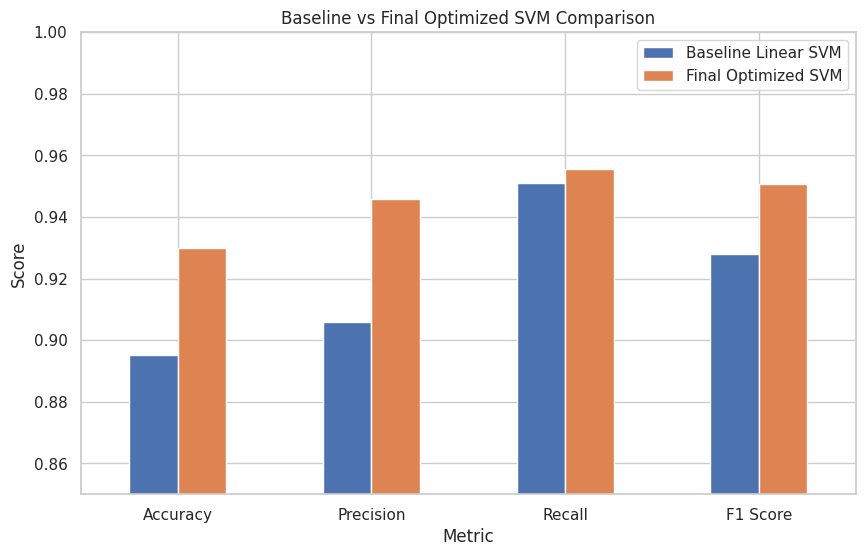

In [ ]:
# =========================
# STEP 13: FINAL OPTIMIZED SVM MODEL
# Selected Configuration:
# Kernel = RBF | C = 10 | Gamma = scale
# =========================

# Train final optimized model
final_svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=42
)

final_svm.fit(X_train_80, y_train_80)

# Predictions
y_pred_final = final_svm.predict(X_test_80)

# -------------------------
# Final Performance Metrics
# -------------------------
final_accuracy = accuracy_score(y_test_80, y_pred_final)
final_precision = precision_score(y_test_80, y_pred_final)
final_recall = recall_score(y_test_80, y_pred_final)
final_f1 = f1_score(y_test_80, y_pred_final)

print("Final Optimized SVM Performance:\n")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall: {final_recall:.4f}")
print(f"F1 Score: {final_f1:.4f}")

# -------------------------
# Confusion Matrix
# -------------------------
cm_final = confusion_matrix(y_test_80, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title("Final Optimized SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# -------------------------
# Classification Report
# -------------------------
print("\nFinal Classification Report:\n")
print(classification_report(y_test_80, y_pred_final))

# -------------------------
# Baseline vs Final Comparison
# -------------------------
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Baseline Linear SVM': [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    'Final Optimized SVM': [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

print("\nBaseline vs Final Model Comparison:\n")
print(comparison_df)

# Visualization
comparison_df.set_index('Metric').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Baseline vs Final Optimized SVM Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.85, 1.0)
plt.show()

5-Fold Cross-Validation Accuracy Scores:

[0.92333333 0.924      0.928      0.92533333 0.926     ]

Mean CV Accuracy: 0.9253
Standard Deviation: 0.0016


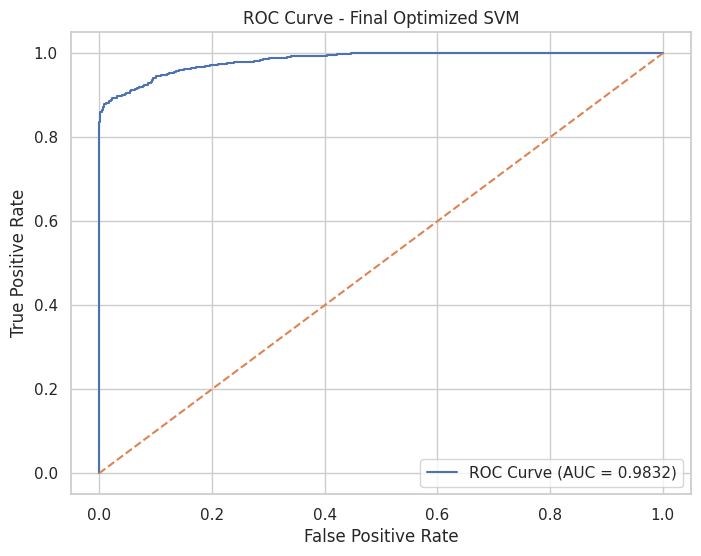


ROC-AUC Score: 0.9832


In [ ]:
# =========================
# STEP 14: CROSS-VALIDATION + ROC CURVE
# Final Model Validation
# =========================

from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc

# -------------------------
# Cross-Validation
# -------------------------
cv_scores = cross_val_score(
    final_svm,
    X_standard_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("5-Fold Cross-Validation Accuracy Scores:\n")
print(cv_scores)

print(f"\nMean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

# -------------------------
# ROC Curve
# -------------------------
# Need probability estimates
final_svm_prob = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

final_svm_prob.fit(X_train_80, y_train_80)

# Probability predictions
y_probs = final_svm_prob.predict_proba(X_test_80)[:, 1]

# ROC metrics
fpr, tpr, thresholds = roc_curve(y_test_80, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Optimized SVM")
plt.legend()
plt.show()

print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Trial B - Retaining column addiction_level

Missing values after imputation:
0

Phase B Feature Correlation with Target:

addicted_label             1.000000
addiction_level            0.706638
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
social_media_hours         0.414244
sleep_hours                0.035496
app_opens_per_day          0.011041
gaming_hours               0.008485
age                        0.004220
stress_level               0.003970
work_study_hours           0.001103
academic_work_impact       0.000072
notifications_per_day     -0.000660
gender                    -0.003499
Name: addicted_label, dtype: float64

Selected Features using Correlation Filter:
['addiction_level', 'daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours', 'sleep_hours', 'app_opens_per_day']

Selected Features using RFE:
Index(['gender', 'daily_screen_time_hours', 'social_media_hours',
       'sleep_hours', 'weekend_screen_time', 'stress_level',
       'addiction_level'],
      dtype='object')

F

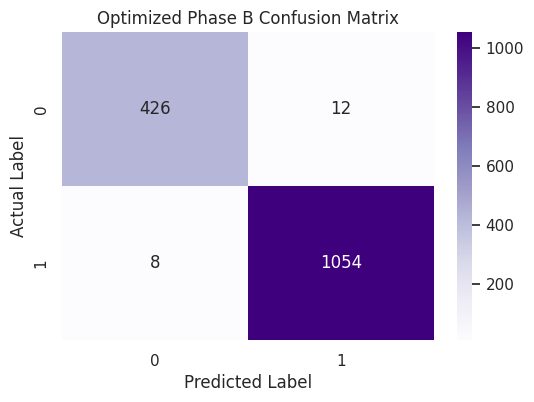


Optimized Phase B Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       438
           1       0.99      0.99      0.99      1062

    accuracy                           0.99      1500
   macro avg       0.99      0.98      0.98      1500
weighted avg       0.99      0.99      0.99      1500


Final Pipeline Comparison:

      Metric   Phase A  Phase B Basic  Phase B Optimized
0   Accuracy  0.930000       0.967333           0.986667
1  Precision  0.945946       0.970288           0.988743
2     Recall  0.955744       0.983992           0.992467
3   F1 Score  0.950820       0.977092           0.990602


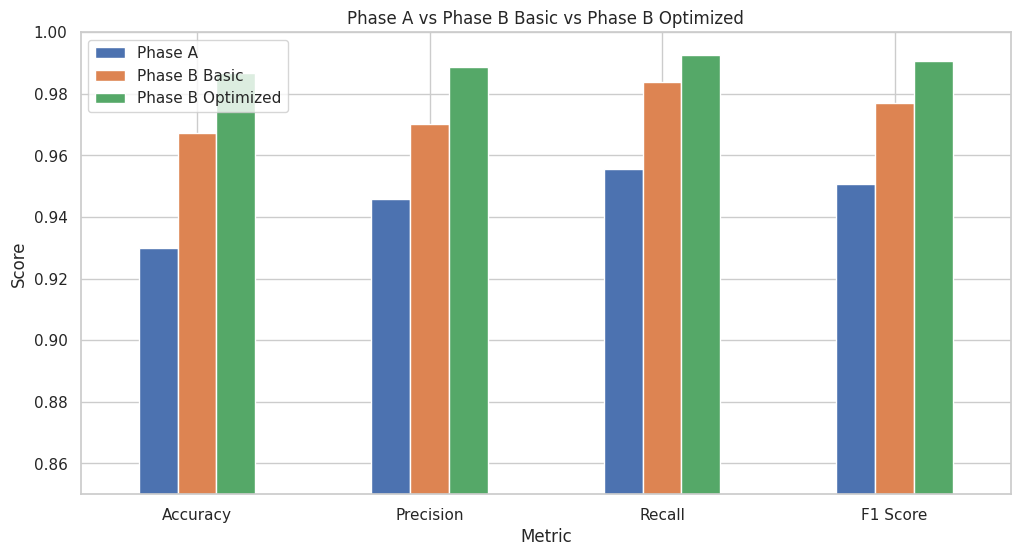

In [ ]:
# =========================
# Trial B
# Retain addiction_level + Mode Imputation + Feature Selection + Final SVM
# =========================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# STEP 15A: Reload Dataset
# -------------------------
df_phase_b = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

# -------------------------
# STEP 15B: Missing Value Handling
# -------------------------
mode_value = df_phase_b['addiction_level'].mode()[0]
df_phase_b['addiction_level'].fillna(mode_value, inplace=True)

print("Missing values after imputation:")
print(df_phase_b['addiction_level'].isnull().sum())

# -------------------------
# STEP 15C: Drop irrelevant columns
# -------------------------
df_phase_b.drop(columns=['transaction_id', 'user_id'], inplace=True)

# -------------------------
# STEP 15D: Label Encoding
# -------------------------
categorical_cols_b = df_phase_b.select_dtypes(include=['object']).columns

label_encoders_b = {}

for col in categorical_cols_b:
    le = LabelEncoder()
    df_phase_b[col] = le.fit_transform(df_phase_b[col])
    label_encoders_b[col] = le

# -------------------------
# STEP 15E: Correlation Filter
# -------------------------
correlation_matrix_b = df_phase_b.corr()

target_corr_b = correlation_matrix_b['addicted_label'].sort_values(ascending=False)

print("\nPhase B Feature Correlation with Target:\n")
print(target_corr_b)

threshold_b = 0.01

selected_features_filter_b = target_corr_b[
    abs(target_corr_b) > threshold_b
].index.tolist()

if 'addicted_label' in selected_features_filter_b:
    selected_features_filter_b.remove('addicted_label')

print("\nSelected Features using Correlation Filter:")
print(selected_features_filter_b)

# -------------------------
# STEP 15F: Wrapper Method (RFE)
# -------------------------
X_b_full = df_phase_b.drop('addicted_label', axis=1)
y_b_full = df_phase_b['addicted_label']

svm_estimator_b = SVC(kernel='linear')

rfe_b = RFE(
    estimator=svm_estimator_b,
    n_features_to_select=7
)

rfe_b.fit(X_b_full, y_b_full)

selected_features_rfe_b = X_b_full.columns[rfe_b.support_]

print("\nSelected Features using RFE:")
print(selected_features_rfe_b)

# Feature ranking table
feature_ranking_b = pd.DataFrame({
    'Feature': X_b_full.columns,
    'Rank': rfe_b.ranking_,
    'Selected': rfe_b.support_
}).sort_values(by='Rank')

print("\nFeature Ranking:\n")
print(feature_ranking_b)

# -------------------------
# STEP 15G: Final Feature Set
# -------------------------
X_b_selected = df_phase_b[selected_features_rfe_b]
y_b_selected = df_phase_b['addicted_label']

# -------------------------
# STEP 15H: Standard Scaling
# -------------------------
scaler_b = StandardScaler()

X_b_scaled = scaler_b.fit_transform(X_b_selected)

# -------------------------
# STEP 15I: Train-Test Split
# -------------------------
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b_scaled,
    y_b_selected,
    test_size=0.2,
    random_state=42,
    stratify=y_b_selected
)

# -------------------------
# STEP 15J: Final Optimized SVM
# -------------------------
svm_phase_b_optimized = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=42
)

svm_phase_b_optimized.fit(X_train_b, y_train_b)

y_pred_b_opt = svm_phase_b_optimized.predict(X_test_b)

# -------------------------
# STEP 15K: Performance Metrics
# -------------------------
phase_b_opt_accuracy = accuracy_score(y_test_b, y_pred_b_opt)
phase_b_opt_precision = precision_score(y_test_b, y_pred_b_opt)
phase_b_opt_recall = recall_score(y_test_b, y_pred_b_opt)
phase_b_opt_f1 = f1_score(y_test_b, y_pred_b_opt)

print("\nOptimized Phase B Performance:\n")
print(f"Accuracy: {phase_b_opt_accuracy:.4f}")
print(f"Precision: {phase_b_opt_precision:.4f}")
print(f"Recall: {phase_b_opt_recall:.4f}")
print(f"F1 Score: {phase_b_opt_f1:.4f}")

# -------------------------
# STEP 15L: Confusion Matrix
# -------------------------
cm_b_opt = confusion_matrix(y_test_b, y_pred_b_opt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_b_opt, annot=True, fmt='d', cmap='Purples')
plt.title("Optimized Phase B Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# -------------------------
# STEP 15M: Classification Report
# -------------------------
print("\nOptimized Phase B Classification Report:\n")
print(classification_report(y_test_b, y_pred_b_opt))

# -------------------------
# STEP 15N: Comparative Analysis
# -------------------------
comparison_final = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Phase A': [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ],
    'Phase B Basic': [
        phase_b_accuracy,
        phase_b_precision,
        phase_b_recall,
        phase_b_f1
    ],
    'Phase B Optimized': [
        phase_b_opt_accuracy,
        phase_b_opt_precision,
        phase_b_opt_recall,
        phase_b_opt_f1
    ]
})

print("\nFinal Pipeline Comparison:\n")
print(comparison_final)

# Visualization
comparison_final.set_index('Metric').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Phase A vs Phase B Basic vs Phase B Optimized")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.85, 1.0)
plt.show()